# Student Stress Level and Academic Performance
## EDA and Predictive Modelling

This notebook works through the full analysis pipeline for the Stress Level Dataset — a survey-based dataset that records psychological, environmental, and academic factors for students. The data comes in a deliberately dirty form, so a good chunk of the work here is just getting it into a usable state before anything interesting can happen.

The end goal is to build a regression model that predicts `academic_performance` from the stress-related features. Along the way we also try to understand which factors matter most and how they relate to each other.

**What this notebook covers:**
- Cleaning messy columns with inconsistent formats and missing values
- Exploring distributions, outliers, and feature relationships
- Imputing missing values using KNN
- Engineering composite features to reduce redundancy
- Training and comparing several regression models

---

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

---
## 1. Loading the Data

We start by reading the raw CSV and doing a quick first pass — checking the shape, column names, data types, and basic statistics. This gives us a feel for what we are working with before touching anything.

In [2]:
df = pd.read_csv("../data/raw/StressLevelDataset_dirty.csv")
df.head(10)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1,25.0,3,3.0,Good,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,High
1,6.0,26.0,0,8.0,1,2.0,Average,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,Low
2,5.0,25.0,NaN,6.0,1,2.0,Average,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,Low
3,12.0,23.0,1,10.0,3,1.0,Poor,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,Medium
4,19.0,15.0,1,27.0,5,NaN,Poor,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,High
5,3.0,26.0,0,8.0,1,NaN,Average,NaN,2,3,...,5,5.0,2,4.0,1.0,3.0,1.0,1.0,1.0,Low
6,16.0,11.0,false,22.0,5,3.0,Poor,4.0,4,2,...,2,1.0,5,2.0,5.0,1.0,4.0,5.0,5.0,High
7,8.0,28.0,0,4.0,1,2.0,Average,2.0,1,3,...,5,5.0,2,5.0,NaN,3.0,2.0,2.0,1.0,Low
8,12.0,NaN,0,11.0,3,1.0,Poor,2.0,2,3,...,3,3.0,3,2.0,3.0,2.0,2.0,2.0,3.0,Low
9,20.0,14.0,1,NaN,5,NaN,Poor,5.0,4,2,...,2,2.0,4,2.0,NaN,1.0,5.0,NaN,5.0,High


### Shape of the dataset

In [3]:
df.shape

(1118, 21)

### Column names

In [4]:
df.columns 

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='str')

### Data types and missing value counts

`df.info()` tells us the dtype of each column and shows where the non-null count falls short of the total row count — those are the columns with missing values.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 1039 non-null   float64
 1   self_esteem                   1049 non-null   float64
 2   mental_health_history         1020 non-null   str    
 3   depression                    1063 non-null   float64
 4   headache                      1118 non-null   int64  
 5   blood_pressure                1008 non-null   float64
 6   sleep_quality                 1028 non-null   str    
 7   breathing_problem             1051 non-null   float64
 8   noise_level                   1118 non-null   int64  
 9   living_conditions             1118 non-null   int64  
 10  safety                        1118 non-null   int64  
 11  basic_needs                   1118 non-null   int64  
 12  academic_performance          1118 non-null   float64
 13  study_load    

### Summary statistics

`df.describe()` gives a quick statistical snapshot — mean, standard deviation, min, max, and quartiles for every numeric column. Useful for spotting columns with wildly different scales or suspiciously narrow ranges.

In [6]:
df.describe()

,anxiety_level,self_esteem,depression,headache,blood_pressure,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
count,1039.000000,1049.000000,1063.000000,1118.000000,1008.000000,1051.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1052.000000,1061.000000,995.000000,1039.000000,1017.000000,1027.000000
mean,11.887392,17.843661,12.921919,2.511628,2.177579,2.764986,2.649374,2.516995,2.727191,2.771914,2.769678,2.626118,2.649240,2.641847,1.887437,2.719923,2.751229,2.605648
std,8.603211,9.413546,8.317868,1.407026,0.875130,1.406431,1.322810,1.115199,1.401430,1.428962,1.402595,1.314378,1.379326,1.517167,1.040137,1.430300,1.404458,1.518337
min,0.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,7.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000
50%,11.000000,19.000000,12.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
75%,17.000000,26.000000,19.000000,3.000000,3.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000
max,92.000000,99.000000,59.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000


---
## 2. Checking for Missing Values

Before cleaning anything, it helps to know exactly where the gaps are. The counts below tell us which columns are affected and by how much — that informs whether we can drop rows, fill with a simple statistic, or need something more sophisticated.

In [7]:
df.isna().sum()

anxiety_level                    79
self_esteem                      69
mental_health_history            98
depression                       55
headache                          0
blood_pressure                  110
sleep_quality                    90
breathing_problem                67
noise_level                       0
living_conditions                 0
safety                            0
basic_needs                       0
academic_performance              0
study_load                        0
teacher_student_relationship     66
future_career_concerns           57
social_support                  123
peer_pressure                    79
extracurricular_activities      101
bullying                         91
stress_level                      0
dtype: int64

### Missing value heatmap

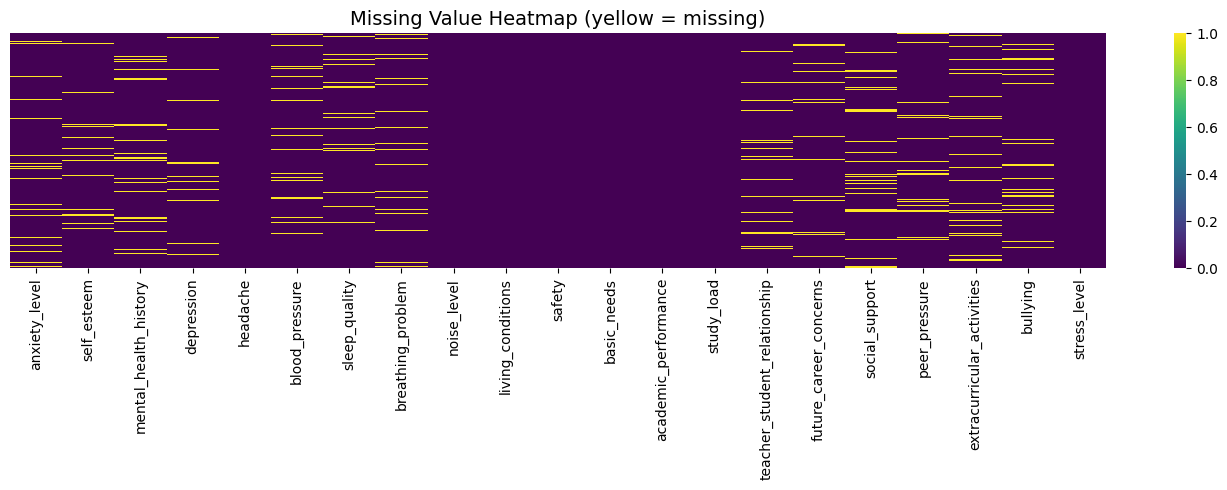

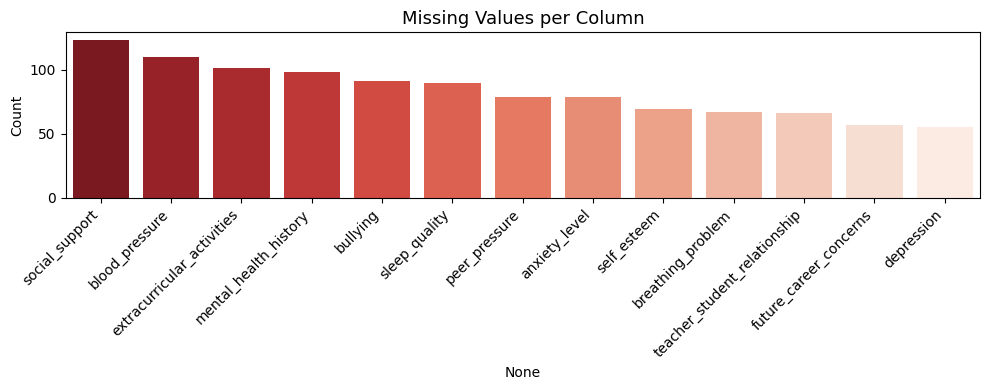

In [8]:
# Missing value heatmap — shows which columns and rows have NaNs
plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap (yellow = missing)', fontsize=14)
plt.tight_layout()
plt.show()

# Bar chart of missing counts per column
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if not missing.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing.index, y=missing.values, palette='Reds_r')
    plt.title('Missing Values per Column', fontsize=13)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the current dataframe state.")

In [9]:
df.dropna(inplace=False)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
6,16.0,11.0,false,22.0,5,3.0,Poor,4.0,4,2,...,2,1.0,5,2.0,5.0,1.0,4.0,5.0,5.0,High
18,18.0,10.0,1,23.0,3,3.0,Poor,5.0,5,1,...,2,2.0,4,1.0,4.0,1.0,4.0,4.0,4.0,High
22,7.0,25.0,0,0.0,1,2.0,Average,2.0,1,4,...,5,4.0,2,5.0,1.0,3.0,1.0,1.0,1.0,Low
25,13.0,24.0,1,10.0,2,1.0,Poor,4.0,2,2,...,2,2.0,3,3.0,3.0,2.0,2.0,2.0,3.0,Medium
27,21.0,28.0,0,20.0,0,3.0,Poor,0.0,5,4,...,4,2.0,4,2.0,0.0,0.0,5.0,0.0,5.0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,16.0,15.0,0,14.0,4,3.0,Average,5.0,1,2,...,5,3.0,1,1.0,1.0,1.0,5.0,2.0,2.0,High
1100,7.0,27.0,0,7.0,1,2.0,Average,2.0,1,4,...,5,4.0,2,4.0,1.0,3.0,1.0,1.0,1.0,Low
1104,21.0,1.0,1,17.0,3,3.0,Poor,4.0,5,1,...,1,1.0,4,2.0,5.0,1.0,5.0,5.0,5.0,High
1107,8.0,25.0,0,5.0,1,2.0,Average,1.0,2,4,...,4,4.0,1,4.0,1.0,3.0,1.0,2.0,1.0,Low


---
## 3. Data Cleaning

### 3.1 Standardising `mental_health_history`

This column is supposed to be a simple yes/no flag, but the raw data has it in half a dozen different formats — `'yes'`, `'no'`, `'true'`, `'false'`, `'1'`, `'0'`, and a few others. We first print the unique values to see exactly what we are dealing with.

In [10]:
temp = df['mental_health_history'].astype(str).str.strip().str.lower()

print(temp.unique())

<StringArray>
['1', '0', nan, 'false', 'n', '1.1', 'y', 'yes', 'true', 'no']
Length: 10, dtype: str


All the truthy variants (`'yes'`, `'true'`, `'1'`, `'y'`) get mapped to 1 and the falsy ones to 0. Anything that does not match either list becomes NaN and is then filled with the column mode, so we do not lose any rows.

In [11]:
temp = df['mental_health_history'].astype(str).str.strip().str.lower()

yes_vals = ['1', 'true', 'yes', 'y']
no_vals = ['0', 'false', 'no', 'n']

temp = temp.apply(lambda x: 1 if (x in yes_vals or x == '1.1') 
                  else (0 if x in no_vals else None))

temp.fillna(temp.mode()[0], inplace=True)

df['mental_health_history'] = temp.astype(int)

In [12]:
df['mental_health_history'].isna().sum()

np.int64(0)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 1039 non-null   float64
 1   self_esteem                   1049 non-null   float64
 2   mental_health_history         1118 non-null   int64  
 3   depression                    1063 non-null   float64
 4   headache                      1118 non-null   int64  
 5   blood_pressure                1008 non-null   float64
 6   sleep_quality                 1028 non-null   str    
 7   breathing_problem             1051 non-null   float64
 8   noise_level                   1118 non-null   int64  
 9   living_conditions             1118 non-null   int64  
 10  safety                        1118 non-null   int64  
 11  basic_needs                   1118 non-null   int64  
 12  academic_performance          1118 non-null   float64
 13  study_load    

In [14]:
df['mental_health_history'][2]


np.int64(0)

### 3.2 Fixing `sleep_quality` and `stress_level`

Both of these are ordinal categories stored as strings. The problems are the same: inconsistent casing, possible whitespace, and missing values. We need to clean them up and then convert them to ordered integers so the model can use them properly.

The encoding we use:
- `sleep_quality`: poor = 0, average = 1, good = 2  
- `stress_level`: Low = 0, Medium = 1, High = 2

Missing values in `sleep_quality` are filled using the most common value within each `stress_level` group, which is a reasonable assumption — students under similar stress tend to sleep similarly. We use sklearn's `OrdinalEncoder` to enforce the correct ordering.

In [15]:
print(df['sleep_quality'].unique())
print(df['stress_level'].unique())

<StringArray>
['Good', 'Average', 'Poor', nan]
Length: 4, dtype: str
<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str


In [16]:
df['sleep_quality'] = (
    df['sleep_quality']
    .astype(str)
    .str.strip()
    .str.lower()
)

df['sleep_quality'].replace('nan', np.nan, inplace=True)

df['sleep_quality'] = df.groupby('stress_level')['sleep_quality'].transform(lambda x: x.fillna(x.mode()[0]))

In [17]:
df['sleep_quality'].isna().sum()

np.int64(0)

In [18]:
df['sleep_quality']

0          good
1       average
2       average
3          poor
4          poor
         ...   
1113       poor
1114    average
1115       poor
1116       poor
1117       poor
Name: sleep_quality, Length: 1118, dtype: str

In [19]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[
    ['poor', 'average', 'good'], 
    ['Low', 'Medium', 'High']     
])

df[['sleep_quality', 'stress_level']] = encoder.fit_transform(
    df[['sleep_quality', 'stress_level']]
)

df[['sleep_quality', 'stress_level']] = df[['sleep_quality', 'stress_level']].astype(int)

In [20]:
print(df['stress_level'].unique())
print(df['sleep_quality'].unique())

[2 0 1]
[2 1 0]


In [21]:
df.head(5)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1,25.0,3,3.0,2,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,2
1,6.0,26.0,0,8.0,1,2.0,1,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,0
2,5.0,25.0,0,6.0,1,2.0,1,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,0
3,12.0,23.0,1,10.0,3,1.0,0,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,1
4,19.0,15.0,1,27.0,5,NaN,0,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,2


### Distribution of stress level and sleep quality after encoding

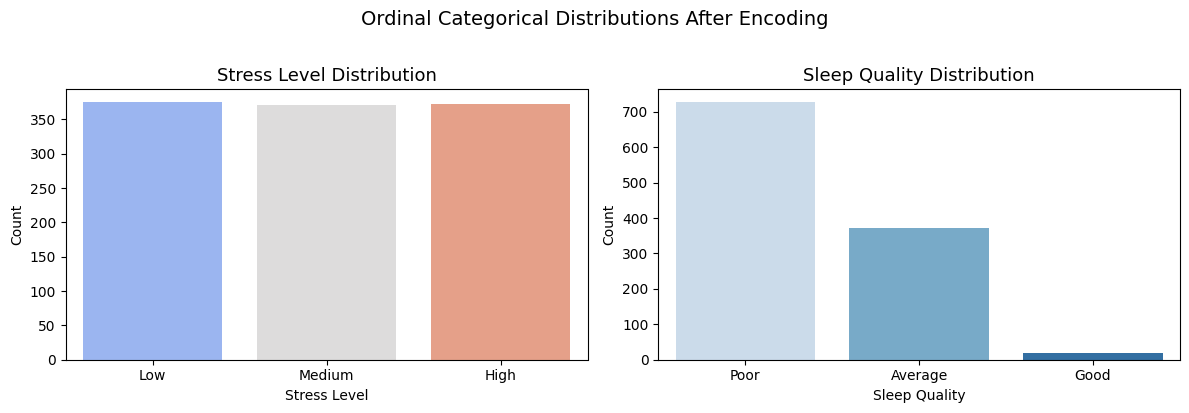

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Stress level distribution
stress_map = {0: 'Low', 1: 'Medium', 2: 'High'}
stress_counts = df['stress_level'].map(stress_map).value_counts()
sns.barplot(x=stress_counts.index, y=stress_counts.values,
            palette='coolwarm', order=['Low', 'Medium', 'High'], ax=axes[0])
axes[0].set_title('Stress Level Distribution', fontsize=13)
axes[0].set_xlabel('Stress Level')
axes[0].set_ylabel('Count')

# Sleep quality distribution
sleep_map = {0: 'Poor', 1: 'Average', 2: 'Good'}
sleep_counts = df['sleep_quality'].map(sleep_map).value_counts()
sns.barplot(x=sleep_counts.index, y=sleep_counts.values,
            palette='Blues', order=['Poor', 'Average', 'Good'], ax=axes[1])
axes[1].set_title('Sleep Quality Distribution', fontsize=13)
axes[1].set_xlabel('Sleep Quality')
axes[1].set_ylabel('Count')

plt.suptitle('Ordinal Categorical Distributions After Encoding', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Exploratory Data Analysis

### 4.1 Distributions of all features

A histogram grid gives a first look at how each numeric column is distributed — whether values cluster, spread out evenly, or pile up at the extremes.

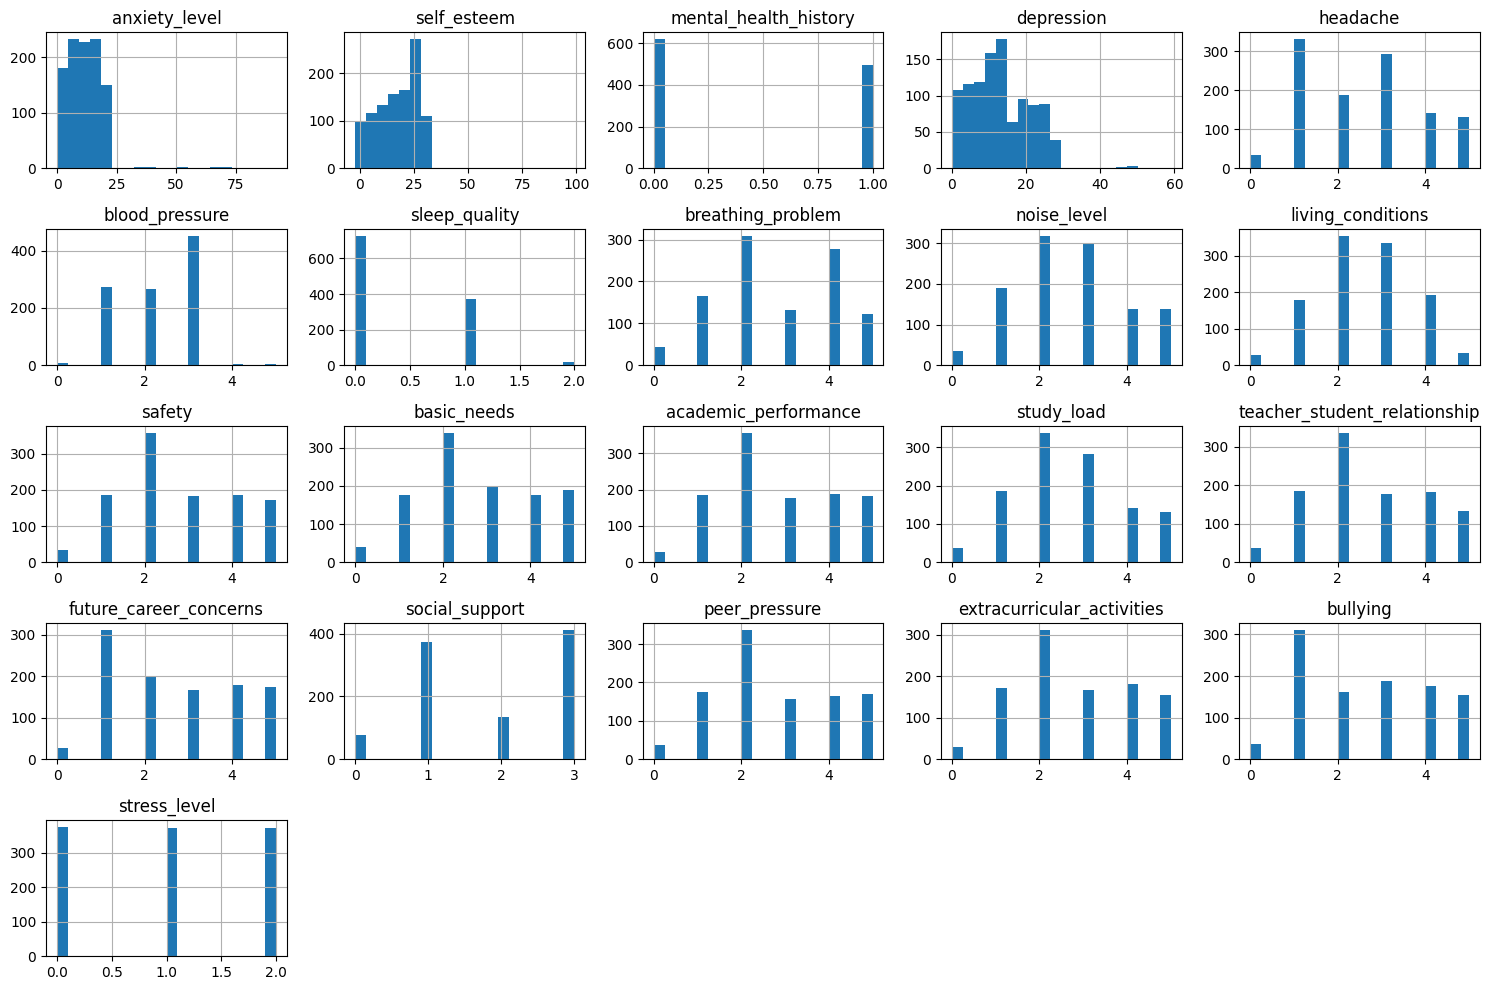

In [23]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

### Correlation heatmap

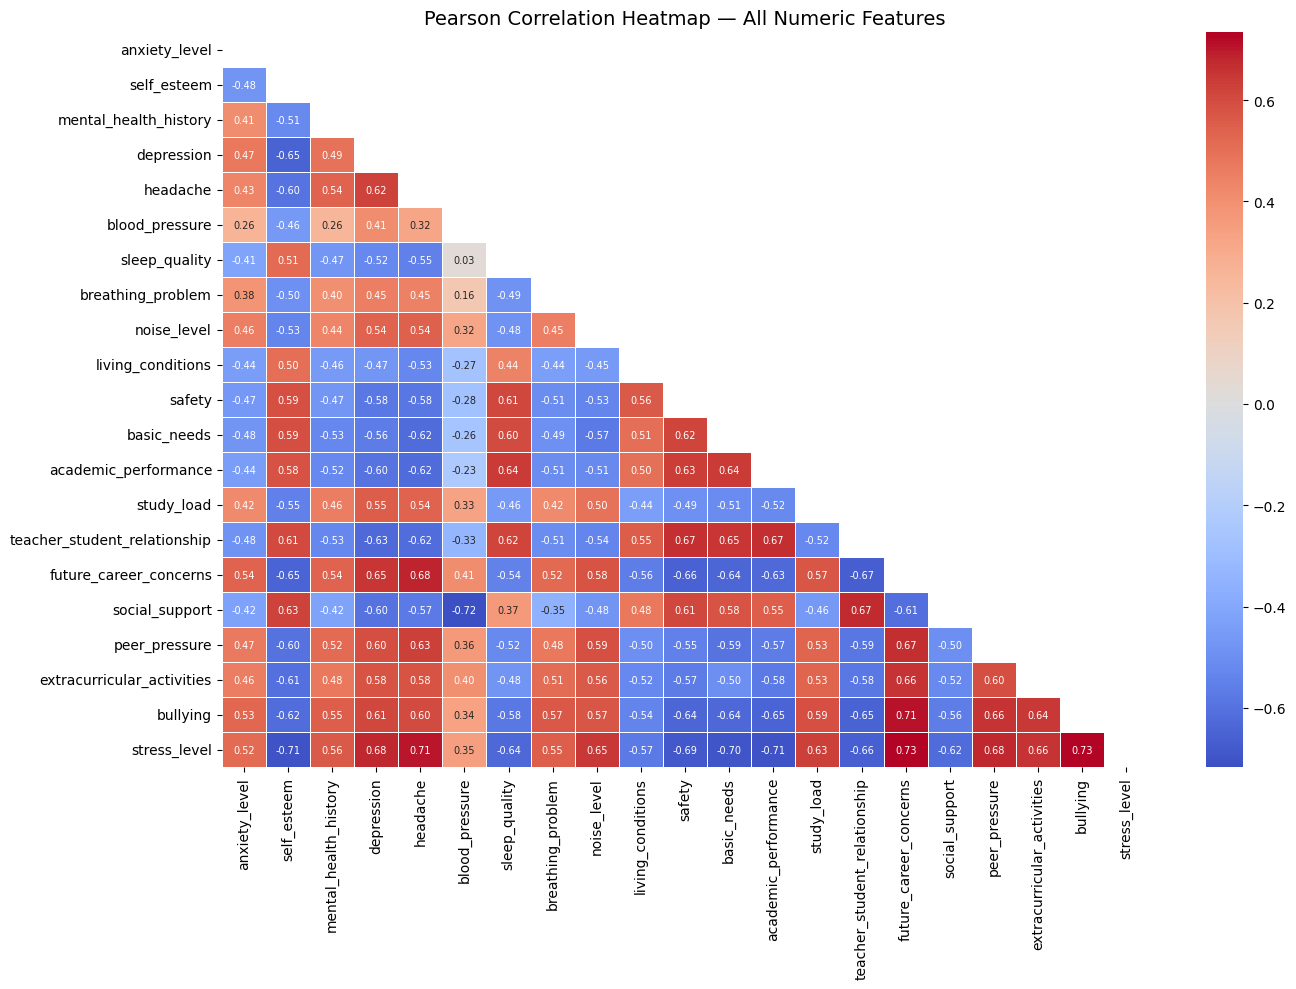

In [24]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Pearson Correlation Heatmap — All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

### 4.2 Outlier detection — before treatment

Boxplots are a straightforward way to see how spread out each feature is and whether any extreme values are pulling things out of shape. Long whiskers or dots beyond the fence are the giveaway.

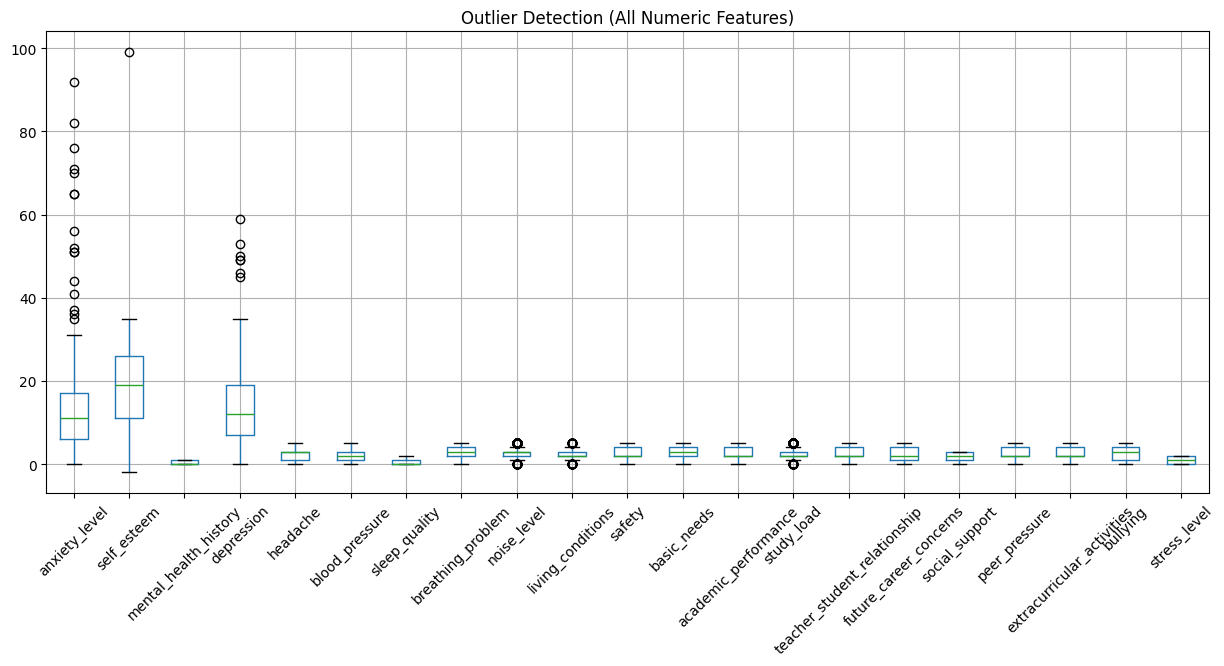

In [25]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.boxplot(figsize=(15,6))
plt.title("Outlier Detection (All Numeric Features)")
plt.xticks(rotation=45)
plt.show()

### 4.3 Handling outliers — percentile capping

Three columns — `anxiety_level`, `self_esteem`, and `depression` — have noticeable outliers. Rather than dropping those rows entirely, we clip values to the 1st and 99th percentiles. This keeps every sample in the dataset but stops the extreme values from having outsized influence on the model. The rest of the distribution stays untouched.

In [26]:
for col in ['anxiety_level', 'self_esteem', 'depression']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

### 4.4 Outlier detection — after treatment

Repeating the boxplots confirms the extreme whiskers are gone. The bulk of each distribution is unchanged.

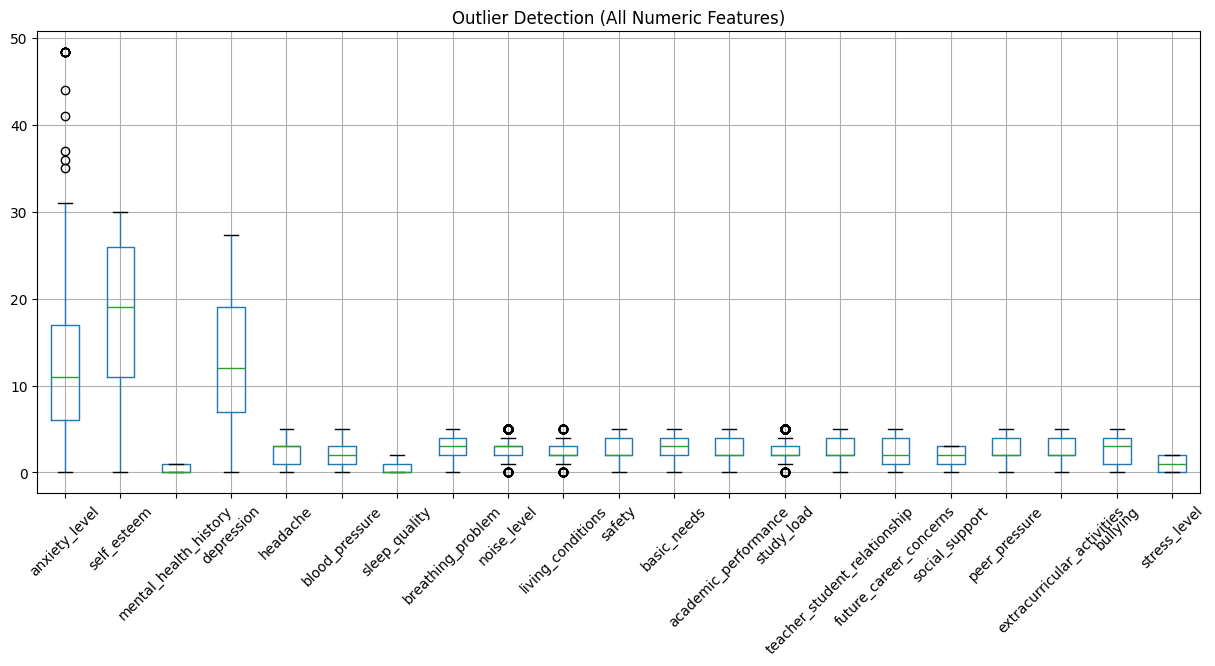

In [27]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.boxplot(figsize=(15,6))
plt.title("Outlier Detection (All Numeric Features)")
plt.xticks(rotation=45)
plt.show()

### KDE plots for the three clipped features

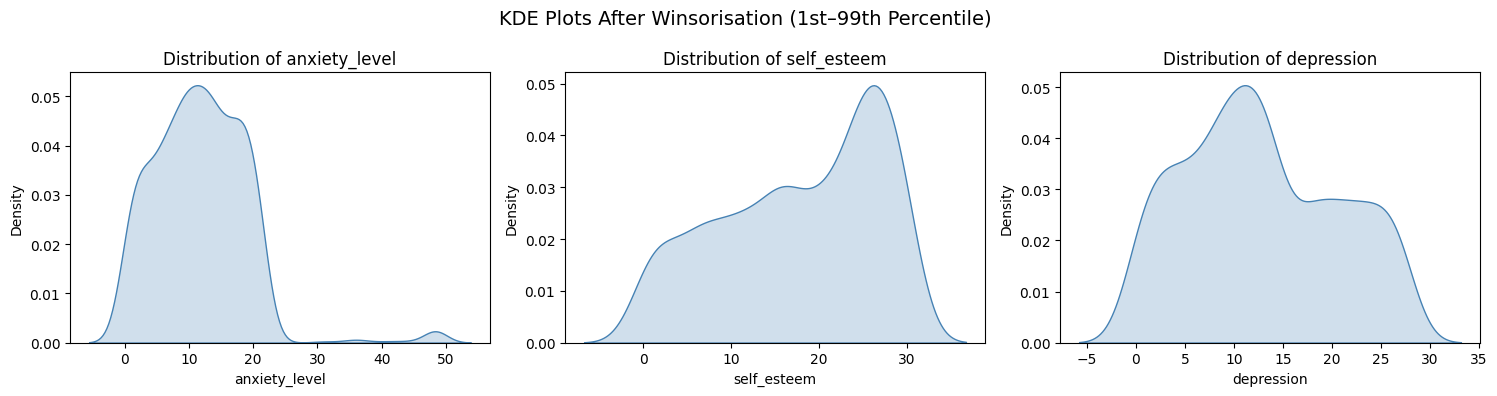

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['anxiety_level', 'self_esteem', 'depression']):
    sns.kdeplot(df[col], fill=True, color='steelblue', ax=ax)
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.suptitle('KDE Plots After Winsorisation (1st–99th Percentile)', fontsize=14)
plt.tight_layout()
plt.show()

### Feature distributions after outlier treatment

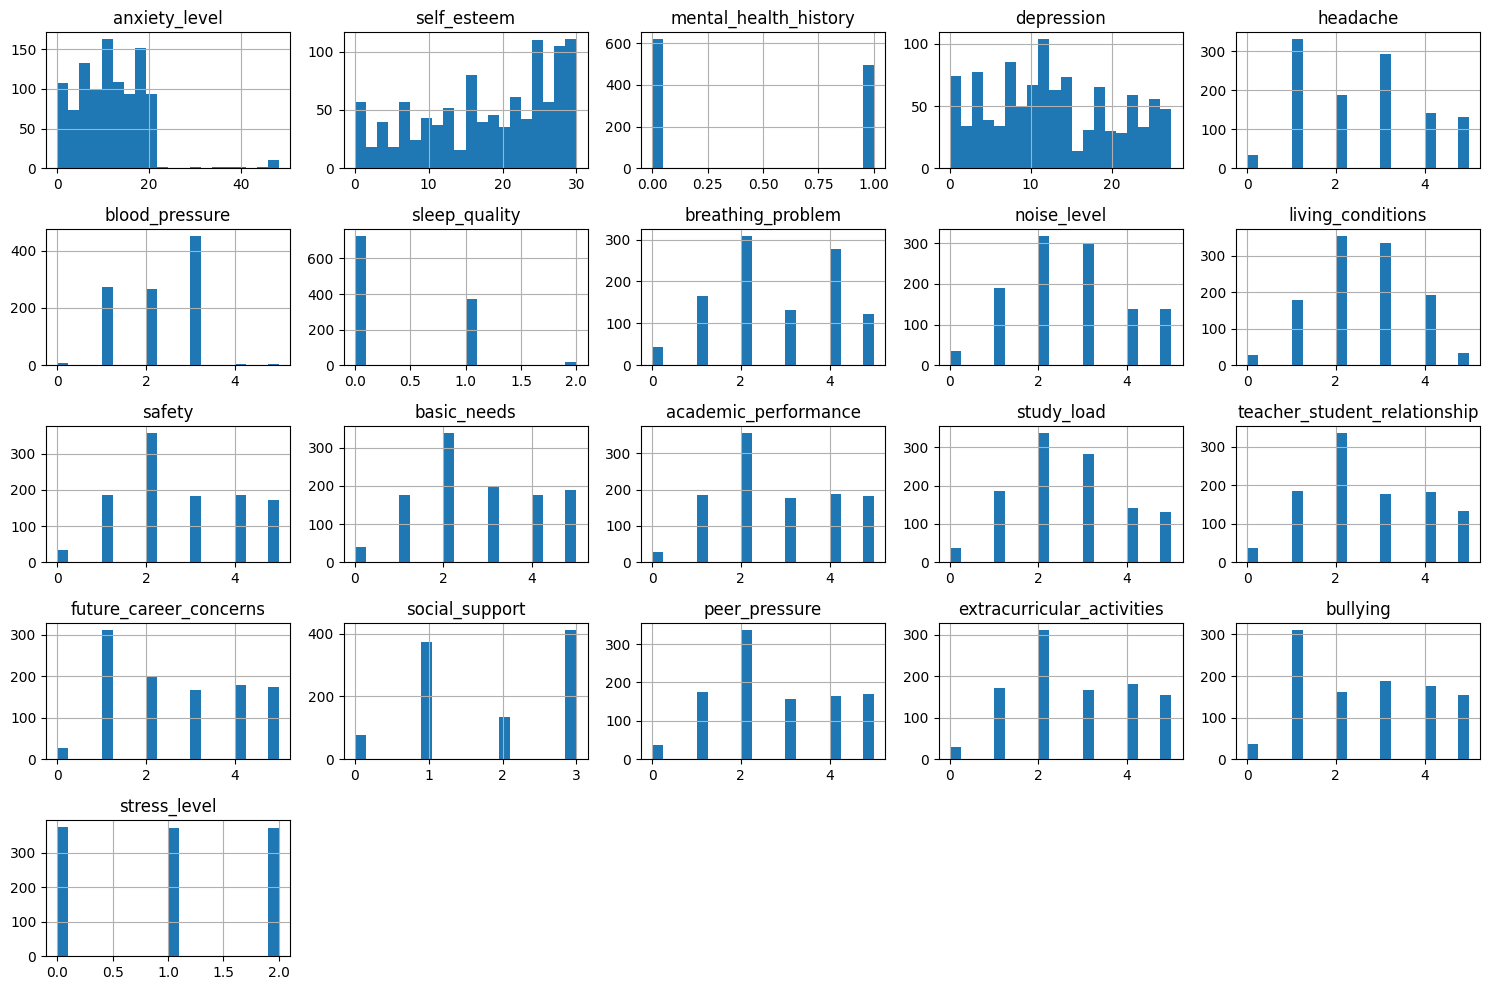

In [29]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

### Pairplot — key psychological features coloured by stress level

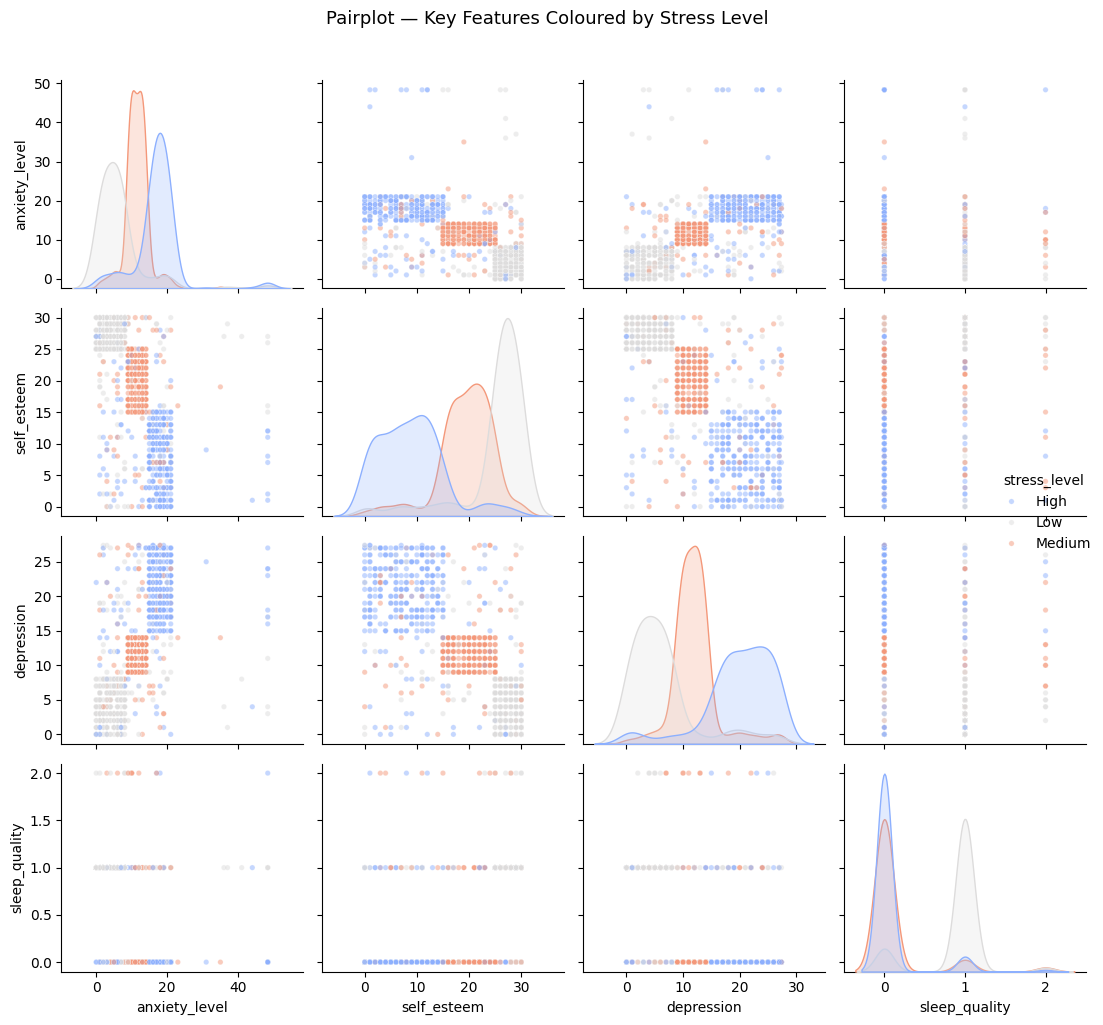

In [30]:
key_cols = ['anxiety_level', 'self_esteem', 'depression',
             'sleep_quality', 'stress_level']
pair_df = df[key_cols].copy()
pair_df['stress_level'] = pair_df['stress_level'].map({0: 'Low', 1: 'Medium', 2: 'High'})

sns.pairplot(pair_df, hue='stress_level', palette='coolwarm',
             plot_kws={'alpha': 0.5, 's': 15}, diag_kind='kde')
plt.suptitle('Pairplot — Key Features Coloured by Stress Level', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Imputing Missing Values

### Why KNN?

After the cleaning steps above, some columns still have missing values. We use K-Nearest Neighbours imputation rather than a simple mean or median fill because KNN looks at similar rows (based on the other features) to estimate what the missing value should be. This means it respects the relationships between features rather than treating each column in isolation.

A few things worth noting about the setup:
- The target column `academic_performance` is separated out first — we never impute the target.
- Everything is scaled with `StandardScaler` before KNN runs, since the algorithm relies on distance and unscaled features would skew it.
- After imputation, ordinal columns are rounded back to integers, since KNN can produce fractional values that do not make sense for those columns.

We also tried two alternative approaches during development — a hybrid strategy (KNN for the most important columns, median for the rest) and MICE (iterative imputation). Both gave similar/worse results but at higher computational cost, so we stuck with plain KNN.

In [31]:
df.isna().sum()

anxiety_level                    79
self_esteem                      69
mental_health_history             0
depression                       55
headache                          0
blood_pressure                  110
sleep_quality                     0
breathing_problem                67
noise_level                       0
living_conditions                 0
safety                            0
basic_needs                       0
academic_performance              0
study_load                        0
teacher_student_relationship     66
future_career_concerns           57
social_support                  123
peer_pressure                    79
extracurricular_activities      101
bullying                         91
stress_level                      0
dtype: int64

In [32]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd


df_knn = df.copy()

y = df_knn['academic_performance']
X = df_knn.drop('academic_performance', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_scaled)

X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

df_knn = pd.concat([X_imputed, y.reset_index(drop=True)], axis=1)

ordinal_cols = [
    'sleep_quality','stress_level','mental_health_history',
    'headache','noise_level','living_conditions','safety',
    'basic_needs','study_load'
]

df_knn[ordinal_cols] = df_knn[ordinal_cols].round().astype(int)

### Alternative imputation strategies (not used)

The three cells below contain the simple(mean,median,mode), hybrid and MICE approaches we tested. They are left here commented out for reference, in case anyone wants to compare.

In [33]:
# cont_cols = [
#     'anxiety_level',
#     'self_esteem',
#     'depression'
# ]

# # Semi-continuous (bounded numeric)
# semi_cont_cols = [
#     'blood_pressure',
#     'breathing_problem',
#     'teacher_student_relationship',
#     'future_career_concerns',
#     'social_support',
#     'peer_pressure',
#     'extracurricular_activities',
#     'bullying'
# ]

# # Ordinal (ratings)
# ord_cols = [
#     'headache',
#     'noise_level',
#     'living_conditions',
#     'safety',
#     'basic_needs',
#     'study_load'
# ]

# # STEP 2: HANDLE MISSING VALUES

# # Continuous + Semi → MEDIAN
# num_cols = cont_cols + semi_cont_cols
# df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# # Ordinal → MODE
# df[ord_cols] = df[ord_cols].fillna(df[ord_cols].mode().iloc[0])


# print("Remaining NaNs:\n", df.isna().sum())

In [34]:
# from sklearn.impute import KNNImputer
# from sklearn.preprocessing import StandardScaler
# import pandas as pd

# df_hybrid = df.copy()

# # STEP 1: High-impact columns (KNN)

# high_cols = [
#     'teacher_student_relationship',
#     'safety',
#     'basic_needs',
#     'self_esteem'
# ]

# scaler = StandardScaler()
# scaled = scaler.fit_transform(df_hybrid[high_cols])

# imputer = KNNImputer(n_neighbors=5)
# df_hybrid[high_cols] = imputer.fit_transform(scaled)

# # STEP 2: Medium + Low → median

# rest_cols = df_hybrid.columns.difference(high_cols + ['academic_performance'])
# df_hybrid[rest_cols] = df_hybrid[rest_cols].fillna(df_hybrid[rest_cols].median())

# ordinal_cols = [
#     'sleep_quality','stress_level','mental_health_history',
#     'headache','noise_level','living_conditions','safety',
#     'basic_needs','study_load'
# ]

# df_hybrid[ordinal_cols] = df_hybrid[ordinal_cols].round().astype(int)

In [35]:
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer
# from sklearn.preprocessing import StandardScaler
# import pandas as pd
# import numpy as np

# df_iter = df.copy()

# # STEP 1: Separate target

# y = df_iter['academic_performance']
# X = df_iter.drop(columns=['academic_performance'])


# # STEP 2: Scale (IMPORTANT)

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)


# imputer = IterativeImputer(
#     max_iter=10,
#     random_state=42
# )

# X_imputed = imputer.fit_transform(X_scaled)


# X_imputed = scaler.inverse_transform(X_imputed)
# X_imputed = pd.DataFrame(X_imputed, columns=X.columns)


# df_iter = pd.concat([X_imputed, y.reset_index(drop=True)], axis=1)


# ordinal_cols = [
#     'sleep_quality','stress_level','mental_health_history',
#     'headache','noise_level','living_conditions','safety',
#     'basic_needs','study_load'
# ]

# df_iter[ordinal_cols] = df_iter[ordinal_cols].round().astype(int)

### Confirming no missing values remain

In [36]:
df_knn.isna().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
academic_performance            0
dtype: int64

---
## 6. Feature Engineering

### 6.1 Dropping redundant columns

Two columns are dropped before modelling: `noise_level` and `bullying`.

`noise_level` is a rough environmental proxy that overlaps heavily with `living_conditions`. `bullying` has low variance and correlates strongly with `peer_pressure`, so keeping both would introduce redundancy without adding much signal. Dropping them keeps the feature space cleaner.

In [37]:
drop_cols = ['noise_level', 'bullying']

df_fs = df_knn.drop(columns=drop_cols)

### 6.2 Building composite scores

Several groups of features measure related things, and feeding them all in separately makes the model harder to interpret and increases multicollinearity. Instead, we aggregate them into four composite scores that each represent a broader concept:

| Score | Built from | What it captures |
|---|---|---|
| `env_score` | safety + basic_needs + living_conditions | Quality of the student's physical environment |
| `mental_score` | anxiety_level + depression - self_esteem | Net psychological load |
| `pressure_score` | peer_pressure + study_load + future_career_concerns | Academic and social pressure |
| `support_score` | teacher_student_relationship + social_support | External support available to the student |

This compression reflects how these factors tend to co-vary in practice and gives the model cleaner signals to work with.

In [38]:
df_fs['env_score'] = (
    df_fs['safety'] +
    df_fs['basic_needs'] +
    df_fs['living_conditions']
)

df_fs['mental_score'] = (
    df_fs['anxiety_level'] +
    df_fs['depression'] -
    df_fs['self_esteem']
)

df_fs['pressure_score'] = (
    df_fs['peer_pressure'] +
    df_fs['study_load'] +
    df_fs['future_career_concerns']
)

df_fs['support_score'] = (
    df_fs['teacher_student_relationship'] +
    df_fs['social_support']
)

# df_fs['env_score'] = (
#     0.6 * df_fs['safety'] +
#     0.6 * df_fs['basic_needs'] +
#     0.5 * df_fs['living_conditions']
# )
# df_fs['mental_score'] = (
#     0.6 * df_fs['depression'] +
#     0.5 * df_fs['anxiety_level'] -
#     0.6 * df_fs['self_esteem']
# )
# df_fs['pressure_score'] = (
#     0.6 * df_fs['future_career_concerns'] +
#     0.5 * df_fs['peer_pressure'] +
#     0.5 * df_fs['study_load']
# )
# df_fs['support_score'] = (
#     0.6 * df_fs['teacher_student_relationship'] +
#     0.5 * df_fs['social_support']
# )
# drop_cols = [
#     'safety','basic_needs','living_conditions',
#     'anxiety_level','depression','self_esteem',
#     'peer_pressure','study_load','future_career_concerns',
#     'teacher_student_relationship','social_support'
# ]

# df_fs2 = df_fs.drop(columns=drop_cols)
df_fs2 = df_fs 

### Composite feature distributions and their relationship with the target

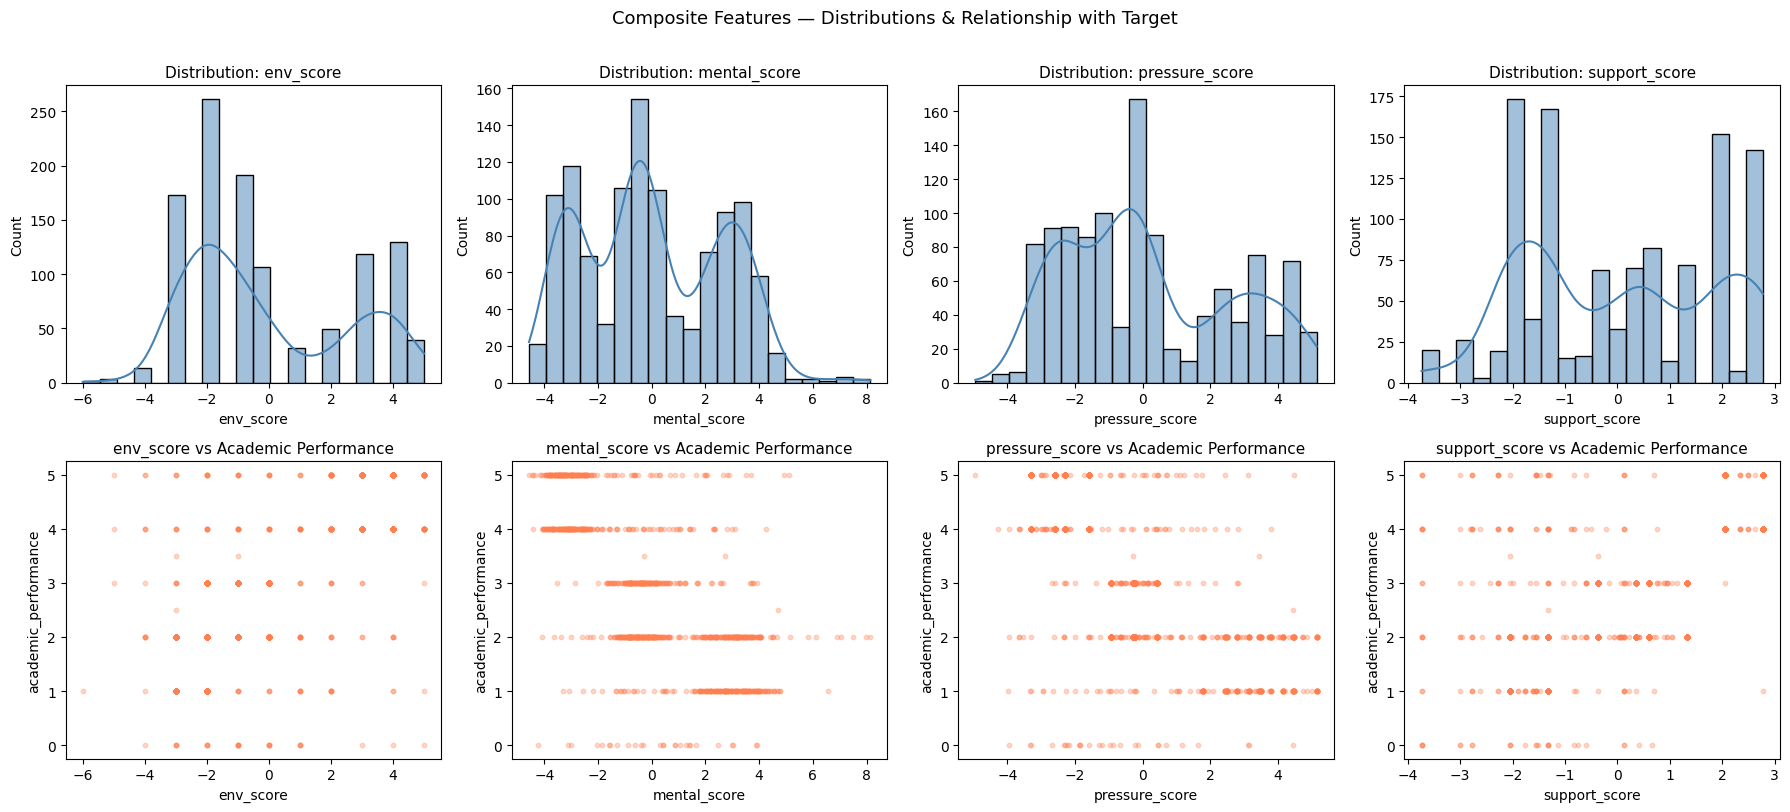

In [39]:
composite_cols = ['env_score', 'mental_score', 'pressure_score', 'support_score']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(composite_cols):
    # Distribution
    sns.histplot(df_fs2[col], kde=True, ax=axes[0, i], color='steelblue', bins=20)
    axes[0, i].set_title(f'Distribution: {col}', fontsize=11)
    axes[0, i].set_xlabel(col)

    # Scatter vs target
    axes[1, i].scatter(df_fs2[col], df_fs2['academic_performance'],
                       alpha=0.3, s=10, color='coral')
    axes[1, i].set_title(f'{col} vs Academic Performance', fontsize=11)
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel('academic_performance')

plt.suptitle('Composite Features — Distributions & Relationship with Target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [40]:
df_fs2.head(5)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,living_conditions,safety,...,future_career_concerns,social_support,peer_pressure,extracurricular_activities,stress_level,academic_performance,env_score,mental_score,pressure_score,support_score
0,0.852404,-1.081449,1,1.569442,0,0.940236,3,1.589895,-1,-1,...,1.555047,-0.853622,1.454994,1.601955,1,1.0,-3,3.503295,5.010041,-1.324539
1,-0.770093,0.909767,-1,-0.610389,-1,-0.203018,1,-0.544179,1,2,...,-1.082690,1.070169,-0.503579,-0.820100,-1,4.0,4,-2.290248,-2.586270,2.049925
2,-0.905301,0.799144,-1,-0.866839,-1,-0.203018,1,-1.255537,1,1,...,-1.082690,1.070169,-0.503579,-1.247521,-1,4.0,3,-2.571284,-1.586270,2.630195
3,0.041156,0.577898,1,-0.353938,0,-1.346273,-1,-0.544179,0,0,...,0.236178,1.070169,-0.503579,0.177217,0,2.0,-1,-0.890680,-0.267401,1.324589
4,0.987612,-0.307087,1,1.825893,2,0.940236,-1,0.878537,0,-1,...,0.895612,-0.853622,0.895402,1.601955,1,2.0,-2,3.120592,3.791014,-2.049876


---
## 7. Modelling

### Setup

The task is a standard regression problem: predict `academic_performance` from the processed features. We test five models, ranging from a simple linear baseline to tuned ensemble methods, so we can see how much complexity actually helps.

| Model | Notes |
|-------|-------|
| Linear Regression | Baseline — interpretable, assumes linearity |
| Ridge | Linear with L2 regularisation to reduce overfitting |
| Lasso | Linear with L1 regularisation; can zero out weak features |
| Lasso | Linear with L1 regularisation; can zero out weak features |
| AdaBoost | Combines weak learners sequentially |
| Gradient Boosting | Builds trees to minimise loss directly |

All models are evaluated with 5-fold cross-validation on the training set and then tested on the held-out 20%. We report R², MAE, and MSE.

### Imports

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

### 7.2 Linear regression baseline

We run Linear Regression first with a `StandardScaler` in the pipeline. The cross-validated R² gives us the floor — any more complex model should clear this.

In [42]:
X = df_fs2.drop(columns=['academic_performance'])
y = df_fs2['academic_performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring='r2'
)

print("CV Scores:", cv_scores)
print("CV Mean :", np.mean(cv_scores))
print("CV Std  :", np.std(cv_scores))

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("\n=== Linear Regression Final Results ===")
print("Train R2 :", r2_score(y_train, train_pred))
print("Test  R2 :", r2_score(y_test, test_pred))
print("MSE      :", mean_squared_error(y_test, test_pred))
print("MAE      :", mean_absolute_error(y_test, test_pred))

CV Scores: [0.64520392 0.57521679 0.4998127  0.53980977 0.62655238]
CV Mean : 0.5773191126945082
CV Std  : 0.053760350051512494

=== Linear Regression Final Results ===
Train R2 : 0.623903140469909
Test  R2 : 0.6294321507456706
MSE      : 0.7713842888423523
MAE      : 0.6794676977240607


### 7.3 Tuning Gradient Boosting

We use `RandomizedSearchCV` with 40 iterations and 5-fold CV to search across `n_estimators`, `learning_rate`, `max_depth`, and `subsample`. Randomised search is more practical than an exhaustive grid here given the size of the parameter space.

In [43]:
gb_model = Pipeline([
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_dist = {
    "model__n_estimators": [50, 100, 150, 200, 300],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.6, 0.7, 0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    gb_model,
    param_distributions=gb_param_dist,
    n_iter=40,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("GradientBoosting Best Params:", gb_search.best_params_)
print("GradientBoosting Best CV Score:", gb_search.best_score_)

GradientBoosting Best Params: {'model__subsample': 0.6, 'model__n_estimators': 100, 'model__max_depth': 4, 'model__learning_rate': 0.03}
GradientBoosting Best CV Score: 0.6038498606387097


### 7.4 Tuning AdaBoost

Same approach for AdaBoost — randomised search over `n_estimators` and `learning_rate`.

In [44]:
ab_model = Pipeline([
    ("model", AdaBoostRegressor(random_state=42))
])

ab_param_dist = {
    "model__n_estimators": [50, 100, 150, 200, 300],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.5, 1.0]
}

ab_search = RandomizedSearchCV(
    ab_model,
    param_distributions=ab_param_dist,
    n_iter=40,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

ab_search.fit(X_train, y_train)

print("AdaBoost Best Params:", ab_search.best_params_)
print("AdaBoost Best CV Score:", ab_search.best_score_)

AdaBoost Best Params: {'model__n_estimators': 50, 'model__learning_rate': 0.01}
AdaBoost Best CV Score: 0.6213144117739504


### 7.5 Tuning Ridge Regression

Ridge adds an L2 penalty to the loss function, which shrinks coefficients and helps when features are correlated. The key hyperparameter is `alpha` — we search across a range spanning several orders of magnitude since the right value is hard to guess upfront.

In [45]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_param_dist = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100]
}

ridge_search = RandomizedSearchCV(
    ridge_model,
    param_distributions=ridge_param_dist,
    n_iter=7,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

print("Best Ridge Params:", ridge_search.best_params_)
print("Best Ridge CV Score:", ridge_search.best_score_)

Best Ridge Params: {'model__alpha': 100}
Best Ridge CV Score: 0.5823364410333143


### 7.6 Tuning Lasso Regression

Lasso uses an L1 penalty instead of L2, which can shrink some coefficients all the way to zero — effectively removing those features from the model. We set `max_iter=10000` to give it enough iterations to converge, since Lasso can be slow to settle at small alpha values.

In [46]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000))
])

lasso_param_dist = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_search = RandomizedSearchCV(
    lasso_model,
    param_distributions=lasso_param_dist,
    n_iter=6,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)

print("Best Lasso Params:", lasso_search.best_params_)
print("Best Lasso CV Score:", lasso_search.best_score_)

Best Lasso Params: {'model__alpha': 0.1}
Best Lasso CV Score: 0.5748044293060696


### 7.7 Final comparison across all models

We now run all four models with their best configurations, record cross-validated and test set metrics, and sort by CV R².

In [47]:
X = df_fs2.drop(columns=['academic_performance'])
y = df_fs2['academic_performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Ridge": ridge_search.best_estimator_,
    "Lasso": lasso_search.best_estimator_,
    "AdaBoost": ab_search.best_estimator_,
    "GradientBoosting": gb_search.best_estimator_
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2')
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "CV Mean": np.mean(cv_scores),
        "CV Std": np.std(cv_scores),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "MSE": mean_squared_error(y_test, test_pred)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="CV Mean", ascending=False)

print(results_df)

              Model   CV Mean    CV Std  Train R2   Test R2       MAE  \
2          AdaBoost  0.611269  0.043705  0.661583  0.692052  0.652931   
3  GradientBoosting  0.598338  0.052994  0.810299  0.643742  0.680483   
0             Ridge  0.589625  0.053380  0.622804  0.634797  0.678222   
1             Lasso  0.584008  0.054903  0.610235  0.626038  0.694664   

        MSE  
2  0.641033  
3  0.741596  
0  0.760216  
1  0.778450  


### Model comparison plots

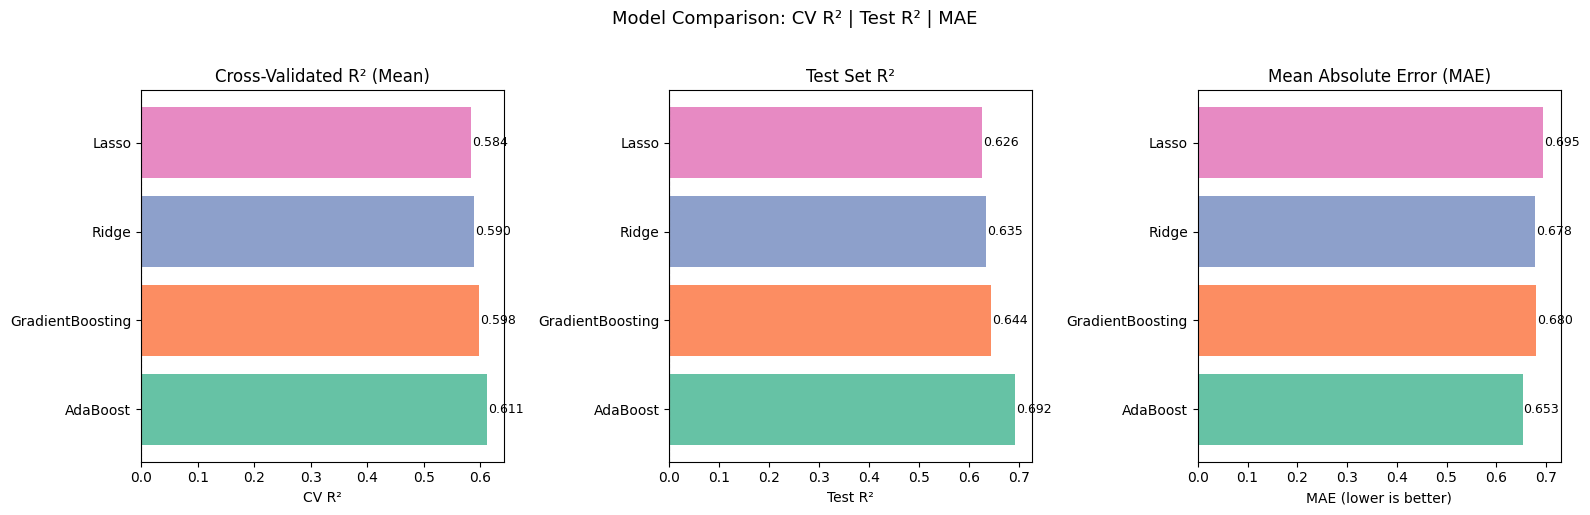

In [48]:
# Assumes results_df is defined from the cell above
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = sns.color_palette('Set2', len(results_df))

# CV Mean R²
bars = axes[0].barh(results_df['Model'], results_df['CV Mean'], color=colors)
axes[0].set_title('Cross-Validated R² (Mean)', fontsize=12)
axes[0].set_xlabel('CV R²')
axes[0].axvline(0, color='grey', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, results_df['CV Mean']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# Test R²
bars2 = axes[1].barh(results_df['Model'], results_df['Test R2'], color=colors)
axes[1].set_title('Test Set R²', fontsize=12)
axes[1].set_xlabel('Test R²')
axes[1].axvline(0, color='grey', linewidth=0.8, linestyle='--')
for bar, val in zip(bars2, results_df['Test R2']):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# MAE
bars3 = axes[2].barh(results_df['Model'], results_df['MAE'], color=colors)
axes[2].set_title('Mean Absolute Error (MAE)', fontsize=12)
axes[2].set_xlabel('MAE (lower is better)')
for bar, val in zip(bars3, results_df['MAE']):
    axes[2].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison: CV R² | Test R² | MAE', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

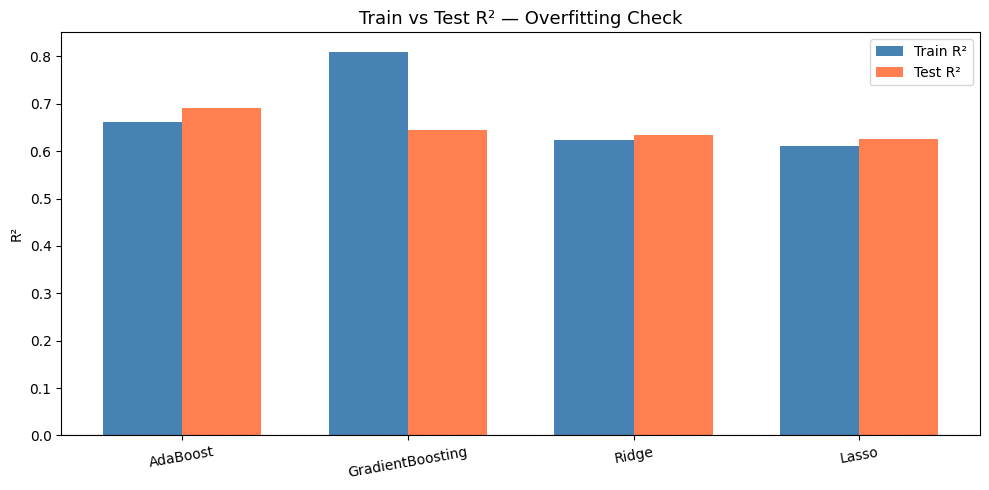

In [49]:
# Train vs Test R² — detect overfitting
x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_train = ax.bar(x - width/2, results_df['Train R2'], width, label='Train R²', color='steelblue')
bars_test = ax.bar(x + width/2, results_df['Test R2'], width, label='Test R²', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=10)
ax.set_ylabel('R²')
ax.set_title('Train vs Test R² — Overfitting Check', fontsize=13)
ax.legend()
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

---
## 8. Summary

### What was done

| Stage | Decisions made |
|-------|---------------|
| Data cleaning | Normalised `mental_health_history` to binary; fixed `sleep_quality` and `stress_level` encoding |
| Outlier treatment | Winsorised three psychological columns at the 1st and 99th percentile |
| Imputation | KNN with k=5 on scaled features; ordinal columns rounded post-imputation |
| Feature engineering | Dropped two redundant columns; built four composite scores |
| Modelling | Compared five regression models; tuned ensembles via randomised search |

### Observations
- The composite features compress correlated sub-features into interpretable dimensions, which helps both the model and the reader.
- Ensemble models (Gradient Boosting, AdaBoost) tend to outperform linear ones, pointing to non-linear structure in the data.
- The gap between training and test R² is worth watching — a large gap means the model is memorising training patterns rather than generalising.

### Possible extensions
- SHAP-based feature importance to understand which scores drive predictions most
- Trying XGBoost or LightGBM for potentially better performance
- Reformulating as classification (Low / Medium / High performance) to see if that framing fits the data better
- Applying the model in a counselling context to flag at-risk students early